In [1]:
#1 Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#2 Loading Cleaned Datasets
customers = pd.read_csv("cleaned_customers.csv")
orders = pd.read_csv("cleaned_orders.csv")
deliveries = pd.read_csv("cleaned_deliveries.csv")
drivers = pd.read_csv("cleaned_drivers.csv")
vehicles = pd.read_csv("cleaned_vehicles.csv")
hubs = pd.read_csv("cleaned_hubs.csv")
complaints = pd.read_csv("cleaned_complaints.csv")
incidents = pd.read_csv("cleaned_incidents.csv")
app_events = pd.read_csv("cleaned_app_events.csv")

print("Datasets loaded successfully")

Datasets loaded successfully


In [3]:
#3 Creating Master Dataset
df = deliveries.merge(orders, on="order_id", how="left") \
               .merge(customers, on="customer_id", how="left") \
               .merge(drivers, on="driver_id", how="left") \
               .merge(vehicles, on="vehicle_id", how="left") \
               .merge(hubs, on="hub_id", how="left")

print("Master dataset created:", df.shape)

Master dataset created: (950, 53)


In [4]:
#4 Driver Risk Analysis
driver_kpi = df.groupby("driver_id").agg(
    total_deliveries=("delivery_id", "count"),
    problem_deliveries=("failed_delivery_flag", "sum"),
    avg_rating=("driver_rating", "mean")
).reset_index()

driver_kpi["problem_rate"] = (driver_kpi["problem_deliveries"] / driver_kpi["total_deliveries"]) * 100

driver_kpi = driver_kpi.sort_values(by="problem_rate", ascending=False).head(10)

driver_kpi

,driver_id,total_deliveries,problem_deliveries,avg_rating,problem_rate
50,D051,2,2,3.58,100.000000
62,D063,3,2,4.03,66.666667
91,D092,5,3,4.24,60.000000
103,D104,7,4,3.45,57.142857
169,D170,4,2,4.48,50.000000
102,D103,4,2,4.40,50.000000
110,D111,4,2,4.12,50.000000
131,D132,4,2,4.20,50.000000
23,D024,8,4,3.35,50.000000
146,D147,2,1,3.80,50.000000


In [5]:
#5 Vehicle Performance Analysis
vehicle_kpi = df.groupby("maintenance_status").agg(
    total_deliveries=("delivery_id", "count"),
    failed_deliveries=("failed_delivery_flag", "sum")
).reset_index()

vehicle_kpi["failure_rate"] = (vehicle_kpi["failed_deliveries"] / vehicle_kpi["total_deliveries"]) * 100

vehicle_kpi

,maintenance_status,total_deliveries,failed_deliveries,failure_rate
0,Active,542,45,8.302583
1,InRepair,254,77,30.314961
2,Scheduled,154,10,6.493506


In [6]:
#6 Complaint Impact Analysis
complaint_df = deliveries.merge(orders, on="order_id") \
                         .merge(complaints, on="order_id", how="left")

complaint_kpi = complaint_df.groupby("delivery_status").agg(
    total_deliveries=("delivery_id", "count"),
    complaints=("complaint_id", "count")
).reset_index()

complaint_kpi["complaint_rate"] = (complaint_kpi["complaints"] / complaint_kpi["total_deliveries"]) * 100

complaint_kpi

,delivery_status,total_deliveries,complaints,complaint_rate
0,Delayed,205,48,23.414634
1,Failed,134,35,26.119403
2,OnTime,634,149,23.501577


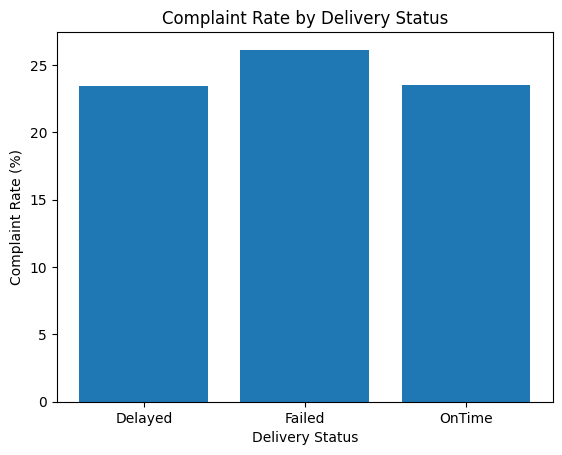

In [7]:
#7 Complaint Rate Visualization
plt.figure()
plt.bar(complaint_kpi["delivery_status"], complaint_kpi["complaint_rate"])
plt.xlabel("Delivery Status")
plt.ylabel("Complaint Rate (%)")
plt.title("Complaint Rate by Delivery Status")
plt.show()

In [10]:
#8 App Event Performance (AUTO SAFE VERSION)

print(app_events.columns)

# Adjust column names automatically
success_col = [col for col in app_events.columns if "success" in col.lower()][0]
latency_col = [col for col in app_events.columns if "latency" in col.lower()][0]

app_kpi = app_events.groupby("event_type").agg(
    total_events=("event_id", "count"),
    failed_events=(success_col, lambda x: (x == 0).sum()),
    avg_latency=(latency_col, "mean")
).reset_index()

app_kpi["failure_rate"] = (app_kpi["failed_events"] / app_kpi["total_events"]) * 100

app_kpi

Index(['event_id', 'customer_id', 'order_id', 'event_timestamp', 'event_type',
       'session_id', 'device_type', 'zone_context', 'api_latency_ms',
       'success_flag', 'event_success_status'],
      dtype='object')


,event_type,total_events,failed_events,avg_latency,failure_rate
0,cancel_attempt,28,0,417.142857,0.000000
1,chat_escalated,38,19,478.131579,50.000000
2,chat_opened,88,0,478.329545,0.000000
3,delivery_instruction_update,75,0,496.293333,0.000000
4,eta_refresh,105,0,452.152381,0.000000
5,payment_retry,69,19,472.681159,27.536232
6,search_route,99,0,456.505051,0.000000
7,track_order,138,0,460.710145,0.000000


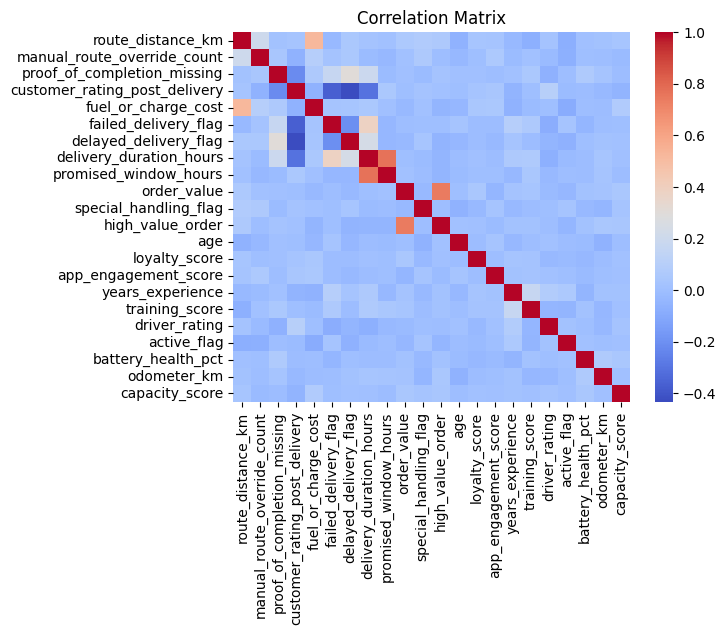

In [13]:
#9 Correlation Matrix
numeric_cols = df.select_dtypes(include=["int64", "float64"])

corr_matrix = numeric_cols.corr()

plt.figure()
sns.heatmap(corr_matrix, cmap="coolwarm")  # changed colour only
plt.title("Correlation Matrix")
plt.show()